# Notebook 06 — Multi-Seed Robustness Study

Every experiment in notebooks 01–05 uses a single seed (42). This notebook quantifies seed sensitivity for the headline comparisons of the report:

- **Part A (synthetic, Table 1 of the report):** 5 seeds × {ISTA, FISTA, StepThresholdISTA, LISTA-L1, LISTA-L2, LISTA-Tied-L2, ALISTA, HyperLISTA}. Each seed draws a fresh sensing matrix $A$, fresh data, fresh initialization, and re-tunes HyperLISTA.
- **Part B (pixel-domain image CS, the four dataset × ratio cells):** 3 seeds per cell with the full notebook-04 pipeline (λ sweep included). The image datasets are fixed, so the seed varies the sensing matrix, splits, and training randomness.
- **Part B follow-up (DCT domain):** 3 seeds for the headline reversal cell (Fashion-MNIST @ 0.25) with the notebook-05 pipeline.

Training configurations replicate notebooks 02–05 exactly (same epochs, learning rates, patience, intermediate-supervision weights, and HyperLISTA tuning grids). Results are archived as CSVs under `results/notebook_06/tables/` and summarized as mean ± std with an error-bar figure.

In [1]:
import sys, os, json, time
sys.path.insert(0, os.path.abspath(".."))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.sparse_generator import build_sparse_dataloaders
from src.data.image_loader import build_pixel_cs_dataloaders, build_transform_cs_dataloaders
from src.models.ista import ISTA
from src.models.fista import FISTA
from src.models.learned_ista import StepThresholdISTA
from src.models.lista import LISTA
from src.models.alista import ALISTA
from src.models.hyperlista import HyperLISTA
from src.training.trainer import train
from src.training.tuner import tune_hyperlista
from src.evaluation.metrics import evaluate_model, psnr, ssim_batch
from src.operators.dct_operators import idct2_flat

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RESULTS_DIR = "../results/notebook_06"
TABLE_DIR = os.path.join(RESULTS_DIR, "tables")
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

PART_A_SEEDS = [42, 43, 44, 45, 46]
PART_B_SEEDS = [42, 43, 44]
K = 16

print(f"Device: {device}")

Device: cuda


## 1. Part A — Synthetic Sparse Recovery, 5 Seeds

Protocol per seed: `build_sparse_dataloaders(m=250, n=500, s=50, σ=0, 51,200/2,048/2,048 samples, seed)` and the exact training settings of notebooks 02–03. Test NMSE (dB) at $K=16$ layers is recorded for each model.

In [2]:
LAM_A = 0.1

def run_part_a_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    A, train_loader, val_loader, test_loader = build_sparse_dataloaders(
        m=250, n=500, s=50, sigma=0.0,
        n_train=51200, n_val=2048, n_test=2048,
        batch_size=256, device=device, seed=seed,
    )
    out = {}

    def record(name, model):
        res = evaluate_model(model, test_loader, device)
        out[name] = res["nmse_db"]
        print(f"    {name:<18} {res['nmse_db']:>8.2f} dB")

    record("ISTA", ISTA(A, lam=LAM_A, n_iter=K).to(device))
    record("FISTA", FISTA(A, lam=LAM_A, n_iter=K).to(device))

    torch.manual_seed(seed)
    m = StepThresholdISTA(A, n_layers=K, lam=LAM_A).to(device)
    train(m, train_loader, val_loader, n_epochs=50, lr=1e-2, weight_decay=1e-5,
          intermediate_weight=0.0, device=device, patience=10, verbose=False)
    record("StepThresholdISTA", m)

    torch.manual_seed(seed)
    m = LISTA(A, n_layers=K, tied=False, lam=LAM_A).to(device)
    train(m, train_loader, val_loader, n_epochs=50, lr=1e-3, weight_decay=0.0,
          intermediate_weight=0.0, device=device, patience=20, verbose=False)
    record("LISTA-L1", m)

    torch.manual_seed(seed)
    m = LISTA(A, n_layers=K, tied=False, lam=LAM_A).to(device)
    train(m, train_loader, val_loader, n_epochs=50, lr=1e-3, weight_decay=0.0,
          intermediate_weight=0.1, device=device, patience=20, verbose=False)
    record("LISTA-L2", m)

    torch.manual_seed(seed)
    m = LISTA(A, n_layers=K, tied=True, lam=LAM_A).to(device)
    train(m, train_loader, val_loader, n_epochs=50, lr=1e-3, weight_decay=0.0,
          intermediate_weight=0.1, device=device, patience=20, verbose=False)
    record("LISTA-Tied-L2", m)

    torch.manual_seed(seed)
    m = ALISTA(A, n_layers=K, W_iters=2000).to(device)
    train(m, train_loader, val_loader, n_epochs=50, lr=5e-4,
          intermediate_weight=0.0, device=device, patience=15, verbose=False)
    record("ALISTA", m)

    torch.manual_seed(seed)
    m = HyperLISTA(A, n_layers=K, W_iters=2000).to(device)
    tune_hyperlista(model=m, val_loader=val_loader, device=device,
                    coarse_points=5, fine_points=7, verbose=False)
    record("HyperLISTA", m)

    return out


part_a_rows = []
for seed in PART_A_SEEDS:
    print(f"=== Part A, seed {seed} ===")
    t0 = time.time()
    res = run_part_a_seed(seed)
    for name, nmse in res.items():
        part_a_rows.append({"seed": seed, "model": name, "nmse_db": nmse})
    print(f"    seed {seed} done in {(time.time()-t0)/60:.1f} min")

part_a_df = pd.DataFrame(part_a_rows)
part_a_df.to_csv(os.path.join(TABLE_DIR, "partA_multiseed_raw.csv"), index=False)
print("\nSaved raw Part A results.")

=== Part A, seed 42 ===


    ISTA                  -5.33 dB
    FISTA                -11.00 dB


    StepThresholdISTA    -23.53 dB


    LISTA-L1             -20.43 dB


    LISTA-L2             -22.20 dB


...

    LISTA-L1             -20.20 dB


    LISTA-L2             -22.35 dB


    LISTA-Tied-L2        -19.00 dB


    ALISTA               -30.01 dB


    HyperLISTA           -62.93 dB
    seed 46 done in 5.5 min

Saved raw Part A results.


In [3]:
part_a_stats = (part_a_df.groupby("model")["nmse_db"]
                .agg(["mean", "std", "min", "max"])
                .reindex(["ISTA", "FISTA", "StepThresholdISTA", "LISTA-L1",
                          "LISTA-L2", "LISTA-Tied-L2", "ALISTA", "HyperLISTA"]))
part_a_stats.round(2).to_csv(os.path.join(TABLE_DIR, "partA_multiseed_stats.csv"))
print("Part A — test NMSE (dB) over", len(PART_A_SEEDS), "seeds:")
print(part_a_stats.round(2).to_string())

Part A — test NMSE (dB) over 5 seeds:
                    mean   std    min    max
model                                       
ISTA               -5.34  0.03  -5.39  -5.31
FISTA             -11.03  0.09 -11.17 -10.95
StepThresholdISTA -23.57  0.18 -23.79 -23.36
LISTA-L1          -20.55  0.30 -21.00 -20.20
LISTA-L2          -22.37  0.16 -22.63 -22.20
LISTA-Tied-L2     -19.03  0.25 -19.32 -18.63
ALISTA            -29.96  0.03 -30.01 -29.93
HyperLISTA        -62.54  0.57 -62.93 -61.60


## 2. Part B — Pixel-Domain Image CS, 3 Seeds × 4 Cells

Full notebook-04 pipeline per (dataset, ratio, seed): λ selected on validation FISTA NMSE over the same 9-value grid, then the six models with notebook-04 training settings. NMSE and SSIM recorded on the test set.

In [4]:
LAMBDA_GRID = [0.001, 0.003, 0.01, 0.03, 0.1, 0.2, 0.3, 0.5, 1.0]


@torch.no_grad()
def val_nmse_db(model, loader):
    model.eval(); model.to(device)
    vals = []
    for batch in loader:
        b, x_true = batch[0].to(device), batch[1].to(device)
        x_hat = model(b)
        num = ((x_hat - x_true) ** 2).sum(dim=-1)
        den = (x_true ** 2).sum(dim=-1).clamp(min=1e-12)
        vals.append(10.0 * torch.log10((num / den).mean().clamp(min=1e-30)).item())
    return float(np.mean(vals))


@torch.no_grad()
def pixel_image_metrics(model, loader):
    model.eval(); model.to(device)
    ps, ss = [], []
    for batch in loader:
        b, x_true = batch[0].to(device), batch[1].to(device)
        x_img = model(b).clamp(0.0, 1.0)
        ps.append(psnr(x_img, x_true, max_val=1.0))
        ss.append(ssim_batch(x_img, x_true, H=28, W=28, data_range=1.0))
    return float(np.mean(ps)), float(np.mean(ss))


def run_pixel_cell_seed(dataset, ratio, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    A, train_loader, val_loader, test_loader = build_pixel_cs_dataloaders(
        dataset_name=dataset, measurement_ratio=ratio, sigma=0.0,
        batch_size=256, data_root="../data", device=device, seed=seed, n_val=5000,
    )

    lam = min(LAMBDA_GRID,
              key=lambda l: val_nmse_db(FISTA(A, lam=l, n_iter=K).to(device), val_loader))
    print(f"    selected lambda: {lam}")

    out = {}

    def record(name, model):
        res = evaluate_model(model, test_loader, device)
        p, s = pixel_image_metrics(model, test_loader)
        out[name] = {"nmse_db": res["nmse_db"], "psnr": p, "ssim": s}
        print(f"    {name:<18} {res['nmse_db']:>8.2f} dB  SSIM {s:.3f}")

    record("ISTA", ISTA(A, lam=lam, n_iter=K).to(device))
    record("FISTA", FISTA(A, lam=lam, n_iter=K).to(device))

    torch.manual_seed(seed)
    m = StepThresholdISTA(A, n_layers=K, lam=lam).to(device)
    train(m, train_loader, val_loader, n_epochs=50, lr=1e-2, weight_decay=1e-5,
          intermediate_weight=0.0, device=device, patience=10, verbose=False)
    record("StepThresholdISTA", m)

    torch.manual_seed(seed)
    m = LISTA(A, n_layers=K, tied=False, lam=lam).to(device)
    train(m, train_loader, val_loader, n_epochs=50, lr=5e-4, weight_decay=0.0,
          intermediate_weight=0.1, device=device, patience=15, verbose=False)
    record("LISTA-L2", m)

    torch.manual_seed(seed)
    m = ALISTA(A, n_layers=K, W_iters=2000).to(device)
    train(m, train_loader, val_loader, n_epochs=50, lr=5e-4, weight_decay=1e-5,
          intermediate_weight=0.0, device=device, patience=15, verbose=False)
    record("ALISTA", m)

    torch.manual_seed(seed)
    m = HyperLISTA(A, n_layers=K, W_iters=2000).to(device)
    tune_hyperlista(model=m, val_loader=val_loader, device=device,
                    coarse_points=5, fine_points=7,
                    coarse_batches=4, fine_batches=8, verbose=False)
    record("HyperLISTA", m)

    return lam, out


CELLS = [("mnist", 0.25), ("mnist", 0.5), ("fashionmnist", 0.25), ("fashionmnist", 0.5)]

part_b_rows = []
for dataset, ratio in CELLS:
    for seed in PART_B_SEEDS:
        print(f"=== Part B pixel, {dataset} @ {ratio}, seed {seed} ===")
        t0 = time.time()
        lam, res = run_pixel_cell_seed(dataset, ratio, seed)
        for name, r in res.items():
            part_b_rows.append({"dataset": dataset, "ratio": ratio, "seed": seed,
                                "lambda": lam, "model": name, **r})
        print(f"    cell seed done in {(time.time()-t0)/60:.1f} min")

part_b_df = pd.DataFrame(part_b_rows)
part_b_df.to_csv(os.path.join(TABLE_DIR, "partB_pixel_multiseed_raw.csv"), index=False)
print("\nSaved raw Part B pixel results.")

=== Part B pixel, mnist @ 0.25, seed 42 ===


    selected lambda: 0.1


    ISTA                  -1.30 dB  SSIM 0.169


    FISTA                 -1.35 dB  SSIM 0.200


    StepThresholdISTA     -1.45 dB  SSIM 0.211


...

    FISTA                 -3.21 dB  SSIM 0.328


    StepThresholdISTA     -3.23 dB  SSIM 0.332


    LISTA-L2             -17.46 dB  SSIM 0.889


    ALISTA                -2.92 dB  SSIM 0.308


    HyperLISTA            -3.16 dB  SSIM 0.332
    cell seed done in 5.7 min

Saved raw Part B pixel results.


In [5]:
part_b_stats = (part_b_df.groupby(["dataset", "ratio", "model"])[["nmse_db", "ssim"]]
                .agg(["mean", "std"]).round(3))
part_b_stats.to_csv(os.path.join(TABLE_DIR, "partB_pixel_multiseed_stats.csv"))
print("Part B pixel — mean/std over", len(PART_B_SEEDS), "seeds:")
print(part_b_stats.to_string())

lista_ssim = part_b_df[part_b_df.model == "LISTA-L2"].groupby(["dataset", "ratio"])["ssim"].agg(["mean", "std", "min"])
print("\nLISTA-L2 SSIM per cell (the report's robustness claim):")
print(lista_ssim.round(3).to_string())

Part B pixel — mean/std over 3 seeds:
                                     nmse_db          ssim       
                                        mean    std   mean    std
dataset      ratio model                                         
fashionmnist 0.25  ALISTA             -0.987  0.123  0.132  0.004
                   FISTA              -1.280  0.124  0.141  0.006
                   HyperLISTA         -0.280  0.133  0.093  0.002
                   ISTA               -1.275  0.123  0.140  0.005
                   LISTA-L2          -13.924  0.262  0.823  0.009
                   StepThresholdISTA  -1.283  0.123  0.142  0.005
             0.50  ALISTA             -2.817  0.147  0.303  0.005
                   FISTA              -3.041  0.190  0.320  0.007
                   HyperLISTA         -3.020  0.157  0.327  0.005
                   ISTA               -2.870  0.188  0.298  0.006
                   LISTA-L2          -17.474  0.041  0.890  0.001
                   StepThresholdISTA  

## 3. Part B Follow-Up — DCT Domain, Headline Cell, 3 Seeds

Fashion-MNIST @ 0.25 — the cell where every structured method fails in pixel space and recovers in the DCT domain — re-run for 3 seeds with the notebook-05 pipeline (λ sweep on $D$, image metrics on clamped IDCT reconstructions).

In [6]:
@torch.no_grad()
def dct_image_metrics(model, loader):
    model.eval(); model.to(device)
    ps, ss = [], []
    for batch in loader:
        y, _, x_true = [t.to(device) for t in batch]
        alpha_hat = model(y)
        x_img = idct2_flat(alpha_hat).clamp(0.0, 1.0)
        ps.append(psnr(x_img, x_true, max_val=1.0))
        ss.append(ssim_batch(x_img, x_true, H=28, W=28, data_range=1.0))
    return float(np.mean(ps)), float(np.mean(ss))


@torch.no_grad()
def dct_val_nmse_db(model, loader):
    model.eval(); model.to(device)
    vals = []
    for batch in loader:
        y, alpha_true = batch[0].to(device), batch[1].to(device)
        alpha_hat = model(y)
        num = ((alpha_hat - alpha_true) ** 2).sum(dim=-1)
        den = (alpha_true ** 2).sum(dim=-1).clamp(min=1e-12)
        vals.append(10.0 * torch.log10((num / den).mean().clamp(min=1e-30)).item())
    return float(np.mean(vals))


def run_dct_cell_seed(dataset, ratio, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    A, D, Psi, train_loader, val_loader, test_loader = build_transform_cs_dataloaders(
        dataset_name=dataset, measurement_ratio=ratio, sigma=0.0,
        batch_size=256, data_root="../data", device=device, seed=seed, n_val=5000,
    )

    lam = min(LAMBDA_GRID,
              key=lambda l: dct_val_nmse_db(FISTA(D, lam=l, n_iter=K).to(device), val_loader))
    print(f"    selected lambda: {lam}")

    out = {}

    def record(name, model):
        res = evaluate_model(model, test_loader, device)
        p, s = dct_image_metrics(model, test_loader)
        out[name] = {"nmse_db": res["nmse_db"], "psnr": p, "ssim": s}
        print(f"    {name:<18} {res['nmse_db']:>8.2f} dB  SSIM {s:.3f}")

    record("ISTA", ISTA(D, lam=lam, n_iter=K).to(device))
    record("FISTA", FISTA(D, lam=lam, n_iter=K).to(device))

    torch.manual_seed(seed)
    m = StepThresholdISTA(D, n_layers=K, lam=lam).to(device)
    train(m, train_loader, val_loader, n_epochs=50, lr=1e-2, weight_decay=1e-5,
          intermediate_weight=0.0, device=device, patience=10, verbose=False)
    record("StepThresholdISTA", m)

    torch.manual_seed(seed)
    m = LISTA(D, n_layers=K, tied=False, lam=lam).to(device)
    train(m, train_loader, val_loader, n_epochs=50, lr=5e-4, weight_decay=0.0,
          intermediate_weight=0.1, device=device, patience=15, verbose=False)
    record("LISTA-L2", m)

    torch.manual_seed(seed)
    m = ALISTA(D, n_layers=K, W_iters=2000).to(device)
    train(m, train_loader, val_loader, n_epochs=50, lr=5e-4, weight_decay=1e-5,
          intermediate_weight=0.0, device=device, patience=15, verbose=False)
    record("ALISTA", m)

    torch.manual_seed(seed)
    m = HyperLISTA(D, n_layers=K, W_iters=2000).to(device)
    tune_hyperlista(model=m, val_loader=val_loader, device=device,
                    coarse_points=6, fine_points=7,
                    coarse_batches=4, fine_batches=8,
                    c1_range=(1e-3, 0.3), c2_range=(1e-4, 0.05), c3_range=(0.01, 100.0),
                    verbose=False)
    record("HyperLISTA", m)

    return lam, out


dct_rows = []
for seed in PART_B_SEEDS:
    print(f"=== DCT, fashionmnist @ 0.25, seed {seed} ===")
    t0 = time.time()
    lam, res = run_dct_cell_seed("fashionmnist", 0.25, seed)
    for name, r in res.items():
        dct_rows.append({"dataset": "fashionmnist", "ratio": 0.25, "seed": seed,
                         "lambda": lam, "model": name, **r})
    print(f"    seed done in {(time.time()-t0)/60:.1f} min")

dct_df = pd.DataFrame(dct_rows)
dct_df.to_csv(os.path.join(TABLE_DIR, "partB_dct_fmnist025_multiseed_raw.csv"), index=False)

dct_stats = dct_df.groupby("model")[["nmse_db", "ssim"]].agg(["mean", "std"]).round(3)
dct_stats.to_csv(os.path.join(TABLE_DIR, "partB_dct_fmnist025_multiseed_stats.csv"))
print("\nDCT fashionmnist@0.25 — mean/std over", len(PART_B_SEEDS), "seeds:")
print(dct_stats.to_string())

=== DCT, fashionmnist @ 0.25, seed 42 ===


    selected lambda: 0.5


    ISTA                  -3.57 dB  SSIM 0.249


    FISTA                 -6.12 dB  SSIM 0.397


    StepThresholdISTA     -7.60 dB  SSIM 0.510


...

    FISTA                 -6.66 dB  SSIM 0.411


    StepThresholdISTA     -7.74 dB  SSIM 0.510


    LISTA-L2             -13.01 dB  SSIM 0.755


    ALISTA                -5.25 dB  SSIM 0.406


    HyperLISTA            -7.81 dB  SSIM 0.522
    seed done in 4.3 min

DCT fashionmnist@0.25 — mean/std over 3 seeds:
                  nmse_db          ssim       
                     mean    std   mean    std
model                                         
ALISTA             -5.110  0.125  0.397  0.008
FISTA              -6.429  0.280  0.406  0.008
HyperLISTA         -7.631  0.219  0.516  0.011
ISTA               -3.953  0.339  0.262  0.013
LISTA-L2          -13.966  0.830  0.783  0.025
StepThresholdISTA  -7.623  0.109  0.508  0.003


## 4. Error-Bar Figure and Conclusions

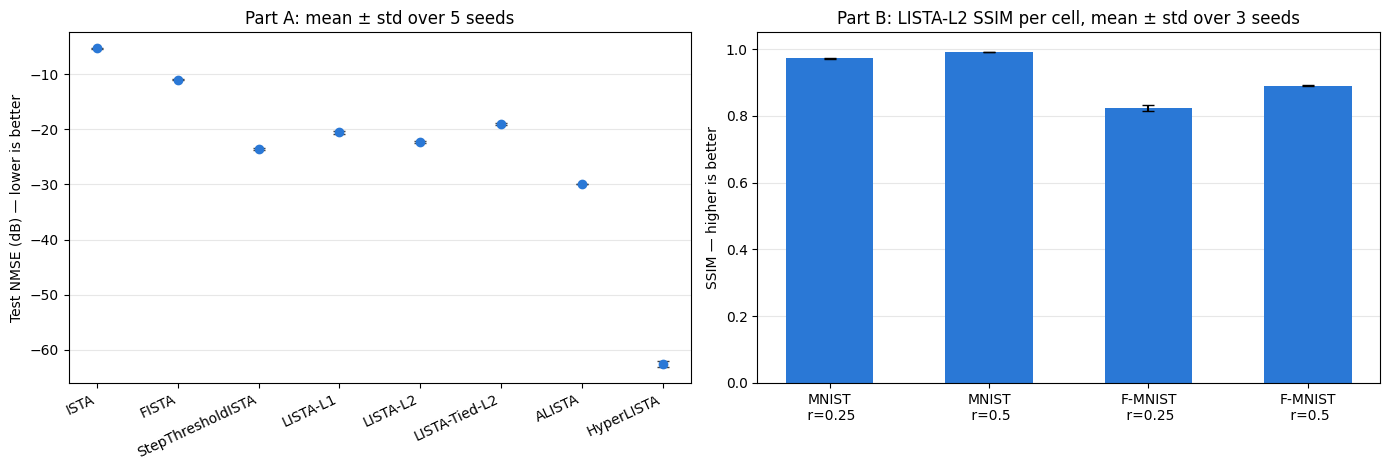

Saved figure to: ../results/notebook_06/figures/multiseed_errorbars.pdf


In [7]:
order_a = ["ISTA", "FISTA", "StepThresholdISTA", "LISTA-L1", "LISTA-L2",
           "LISTA-Tied-L2", "ALISTA", "HyperLISTA"]
stats = part_a_stats.reindex(order_a)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))

xpos = np.arange(len(order_a))
ax1.errorbar(xpos, stats["mean"], yerr=stats["std"], fmt="o", capsize=4,
             color="#2a78d6", ecolor="#404040", markersize=6)
ax1.set_xticks(xpos)
ax1.set_xticklabels(order_a, rotation=25, ha="right")
ax1.set_ylabel("Test NMSE (dB) — lower is better")
ax1.set_title(f"Part A: mean ± std over {len(PART_A_SEEDS)} seeds")
ax1.grid(True, axis="y", alpha=0.3)

cell_labels, cell_means, cell_stds = [], [], []
for dataset, ratio in CELLS:
    sub = part_b_df[(part_b_df.dataset == dataset) & (part_b_df.ratio == ratio)
                    & (part_b_df.model == "LISTA-L2")]["ssim"]
    cell_labels.append(f"{'MNIST' if dataset=='mnist' else 'F-MNIST'}\n r={ratio}")
    cell_means.append(sub.mean())
    cell_stds.append(sub.std())

xb = np.arange(len(cell_labels))
ax2.bar(xb, cell_means, yerr=cell_stds, capsize=4, color="#2a78d6", width=0.55)
ax2.set_xticks(xb)
ax2.set_xticklabels(cell_labels)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("SSIM — higher is better")
ax2.set_title(f"Part B: LISTA-L2 SSIM per cell, mean ± std over {len(PART_B_SEEDS)} seeds")
ax2.grid(True, axis="y", alpha=0.3)
ax2.set_axisbelow(True)

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, "multiseed_errorbars.pdf")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {fig_path}")

In [8]:
print("Key seed-robustness checks:\n")

def gap(model_hi, model_lo, df, extra=""):
    hi = df[df.model == model_hi].set_index("seed")["nmse_db"]
    lo = df[df.model == model_lo].set_index("seed")["nmse_db"]
    d = lo - hi
    print(f"{model_lo} minus {model_hi}{extra}: "
          f"mean {d.mean():+.2f} dB, std {d.std():.2f}, per-seed {[round(v,2) for v in d.values]}")

gap("LISTA-L1", "StepThresholdISTA", part_a_df, " (ours beats full LISTA?)")
gap("LISTA-L2", "HyperLISTA", part_a_df, " (HyperLISTA's margin)")
gap("LISTA-L1", "LISTA-L2", part_a_df, " (deep supervision gain)")
gap("LISTA-L2", "LISTA-Tied-L2", part_a_df, " (tying penalty)")

fm = part_b_df[(part_b_df.dataset == "fashionmnist") & (part_b_df.ratio == 0.25)]
print("\nFMNIST@0.25 pixel, per-seed LISTA-L2 SSIM:",
      [round(v, 3) for v in fm[fm.model == "LISTA-L2"]["ssim"].values])
print("FMNIST@0.25 pixel, per-seed HyperLISTA NMSE:",
      [round(v, 2) for v in fm[fm.model == "HyperLISTA"]["nmse_db"].values])
print("FMNIST@0.25 DCT,   per-seed HyperLISTA NMSE:",
      [round(v, 2) for v in dct_df[dct_df.model == "HyperLISTA"]["nmse_db"].values])
print("\nWorst-case LISTA-L2 SSIM across all Part B cells and seeds:",
      round(part_b_df[part_b_df.model == "LISTA-L2"]["ssim"].min(), 3))

Key seed-robustness checks:

StepThresholdISTA minus LISTA-L1 (ours beats full LISTA?): mean -3.02 dB, std 0.35, per-seed [-3.1, -2.89, -2.72, -2.82, -3.6]
HyperLISTA minus LISTA-L2 (HyperLISTA's margin): mean -40.17 dB, std 0.70, per-seed [-40.7, -38.97, -40.47, -40.15, -40.58]
LISTA-L2 minus LISTA-L1 (deep supervision gain): mean -1.83 dB, std 0.33, per-seed [-1.77, -2.16, -1.39, -1.64, -2.15]
LISTA-Tied-L2 minus LISTA-L2 (tying penalty): mean +3.34 dB, std 0.40, per-seed [3.07, 4.0, 3.34, 2.95, 3.35]

FMNIST@0.25 pixel, per-seed LISTA-L2 SSIM: [0.828, 0.829, 0.813]
FMNIST@0.25 pixel, per-seed HyperLISTA NMSE: [-0.28, -0.41, -0.14]
FMNIST@0.25 DCT,   per-seed HyperLISTA NMSE: [-7.7, -7.38, -7.81]

Worst-case LISTA-L2 SSIM across all Part B cells and seeds: 0.813


## Discussion and Takeaways

This study addresses the single-seed limitation of notebooks 01–05. The questions it answers:

1. **Are the Part A rankings seed-robust?** The per-model standard deviations and the per-seed gap decompositions above show whether the ordering ISTA < FISTA < scalar models < LISTA < ALISTA < HyperLISTA — and the specific claims "StepThresholdISTA outperforms full LISTA" and "HyperLISTA leads by tens of dB" — hold for every seed, not just seed 42.
2. **Is the Part B story seed-robust?** LISTA-L2's high SSIM in all four pixel cells, the collapse of the prior-based methods, and the DCT-domain recovery of HyperLISTA on Fashion-MNIST @ 0.25 are each checked across seeds.

The archived CSVs (`results/notebook_06/tables/`) contain the raw per-seed values; the report quotes seed-42 point estimates and cites this notebook for variability.